In [17]:
import torch

In [18]:
import torch
from torchvision import transforms
from torchvision.models import vit_b_16  # Assuming DINOv2 is available here
from sklearn.cluster import KMeans
import numpy as np
from PIL import Image

import os
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import time

import plotly.graph_objects as go
from IPython.display import HTML

In [40]:
def pad_image_to_size_pil(image, target_size):
    """
    Pads an image to the target size with the image centered using PIL.
    
    :param image: Input image as a PIL Image object.
    :param target_size: Tuple (target_width, target_height).
    :return: Padded image as a PIL Image object.
    """
    original_width, original_height = image.size
    print(image.size)
    target_width, target_height = target_size

    # Create a new image with the target size and a black background
    new_image = Image.new("RGB", target_size, (0, 0, 0))

    # Calculate the position to paste the original image
    paste_position = (
        (target_width - original_width) // 2,
        (target_height - original_height) // 2
    )

    # Paste the original image onto the new image
    new_image.paste(image, paste_position)

    return new_image


In [41]:
# Load the DINOv2 ViT model
model = vit_b_16(pretrained=True)  # Use the appropriate function to load DINOv2
model.eval()  # Set the model to evaluation mode

def process_image(fp):
    im = Image.open(fp)
    target_size = (500, 500)  # Specify your target size
    padded_image = pad_image_to_size_pil(im, target_size)
    # print(f"Image shape (after conversion to RGB): {im.size}")
    im_array = np.array(im)
    im_array_rgb = np.stack([im_array] * 3, axis=-1)
    return encode_image(im_array_rgb)

# transforms.Pad(250),  # Add 250 pixels of padding around the image
# Function to encode an image using DINOv2 ViT
def encode_image(image):
    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    image = preprocess(image).unsqueeze(0)  # Add batch dimension
    with torch.no_grad():
        outputs = model(image)
    return outputs.numpy()  # Assuming the output format is similar

/hawes/projects/OLIVINE/environments/juniorstav/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/hawes/projects/OLIVINE/environments/juniorstav/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [42]:
path_to_grains = '/projects/OLIVINE/data/test_folder_save_grain_img'

In [43]:
image_embeddings = []

In [44]:
for path in tqdm(os.listdir(path_to_grains)):
    embed = process_image(os.path.join(path_to_grains, path))
    image_embeddings.append(embed)

  0%|                                                                                                 | 0/665 [00:00<?, ?it/s]

(251, 142)


  0%|▏                                                                                        | 1/665 [00:00<02:44,  4.04it/s]

(213, 127)


  0%|▎                                                                                        | 2/665 [00:00<02:41,  4.10it/s]

...

100%|██████████████████████████████████████████████████████████████████████████████████████▋| 663/665 [02:40<00:00,  4.13it/s]

(305, 175)


100%|██████████████████████████████████████████████████████████████████████████████████████▊| 664/665 [02:41<00:00,  4.12it/s]

(220, 288)


100%|███████████████████████████████████████████████████████████████████████████████████████| 665/665 [02:41<00:00,  4.12it/s]


In [34]:
np_embed = np.array(image_embeddings)
print(np_embed.shape)
squeezed_array = np.squeeze(np_embed, axis=1)
squeezed_array.shape

(665, 1, 1000)


(665, 1000)

In [35]:
np.savez('squeezed_embeddings.npz', squeezed_array)

In [38]:
# Normalize the embeddings
scaler = StandardScaler()
normalized_embeddings = scaler.fit_transform(squeezed_array)

# Perform t-SNE
start = time.time()
tsne = TSNE(n_components=3, random_state=0, learning_rate=150, perplexity=90, angle=0.5, verbose=2)
projections = tsne.fit_transform(normalized_embeddings)
end = time.time()
print(f"Generating projections with t-SNE took: {(end-start):.2f} sec")


[t-SNE] Computing 271 nearest neighbors...
[t-SNE] Indexed 665 samples in 0.001s...
[t-SNE] Computed neighbors for 665 samples in 0.063s...
[t-SNE] Computed conditional probabilities for sample 665 / 665
[t-SNE] Mean sigma: 12.985895
[t-SNE] Computed conditional probabilities in 0.077s
[t-SNE] Iteration 50: error = 54.2013893, gradient norm = 0.1033097 (50 iterations in 0.514s)
[t-SNE] Iteration 100: error = 56.8912888, gradient norm = 0.0322827 (50 iterations in 0.419s)
[t-SNE] Iteration 150: error = 56.5760269, gradient norm = 0.1316712 (50 iterations in 0.390s)
[t-SNE] Iteration 200: error = 57.8424873, gradient norm = 0.0390772 (50 iterations in 0.427s)
[t-SNE] Iteration 250: error = 57.8591652, gradient norm = 0.3832899 (50 iterations in 0.399s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.859165
[t-SNE] Iteration 300: error = 1.0943346, gradient norm = 0.0028865 (50 iterations in 0.331s)
[t-SNE] Iteration 350: error = 1.0491316, gradient norm = 0.0052490

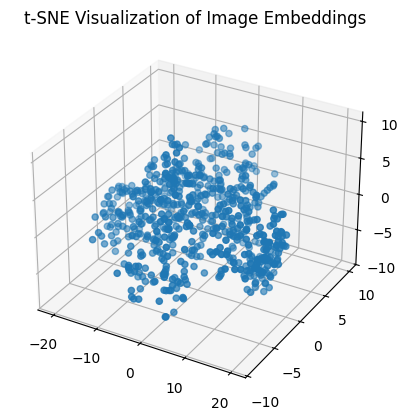

In [37]:
# Visualize the t-SNE projections
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(projections[:, 0], projections[:, 1], projections[:, 2])
plt.title("t-SNE Visualization of Image Embeddings")
plt.show()

In [85]:
# Create the 3D scatter plot using Plotly
fig = go.Figure(data=[go.Scatter3d(x=projections[:, 0], y=projections[:, 1], z=projections[:, 2], mode='markers')])
fig.update_layout(title='t-SNE Visualization of Image Embeddings')

In [86]:

# Save the arrays to an NPZ file
np.savez('embeddings.npz', squeezed_array)